# FID comparison: base inpainting vs base + LoRA

This notebook runs the same masked inpainting inputs through two variants of `stable-diffusion-v1-5/stable-diffusion-inpainting`:

- the base model with no LoRA adapter enabled
- the base model with one selected LoRA adapter loaded

It then computes FID for both generated image sets against the original dataset images. Lower FID is better. For a reliable score, increase `NUM_SAMPLES`; the small defaults are meant to keep a first run fast.

In [1]:
from __future__ import annotations

import json
import math
import shutil
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
from diffusers import StableDiffusionInpaintPipeline
from PIL import Image
from scipy import linalg
from torchvision.models import Inception_V3_Weights, inception_v3


def find_repo_root(start: Path) -> Path:
    """Walk upward until the repository root is found, so the notebook works from any cwd."""
    for path in (start, *start.parents):
        if (path / "backend").exists() and (path / "frontend").exists() and (path / "notebooks").exists():
            return path
    raise RuntimeError("Could not find repository root containing backend/, frontend/, and notebooks/.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
REPO_ROOT

W0528 06:40:27.849000 21216 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


WindowsPath('C:/Users/neman/Documents/UVPython/inpainting')

In [2]:
# -----------------------------
# Experiment configuration
# -----------------------------

# Pick a dataset that contains source images and matching binary masks.
# The default small set is useful for a quick smoke test; use a larger held-out set for real reporting.
DATASET_DIR = REPO_ROOT / "datasets" / "small_house_set"

# Pick the LoRA adapter directory to compare against the base model.
# This can point at a final adapter folder or a checkpoint folder that contains pytorch_lora_weights.safetensors.
LORA_DIR = REPO_ROOT / "notebooks" / "outputs" / "lora_small_house_set_sd15_inpaint"
LORA_ADAPTER_NAME = "selected_lora"
LORA_SCALE = 1.0

# Use the same base model and generation settings as the backend pipeline.
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-inpainting"
RESOLUTION = 512
NUM_INFERENCE_STEPS = 40
GUIDANCE_SCALE = 6.5
STRENGTH = 1.0

# Edit these prompts to match the LoRA being evaluated.
PROMPT = "satellite view of small houses, roof geometry, driveways, residential block"
NEGATIVE_PROMPT = "blurry, distorted, repeated roofs, warped perspective, low quality"

# FID is noisy for tiny batches. The default keeps the first run quick on the small example dataset.
NUM_SAMPLES = 4
SEED = 7
BATCH_SIZE = 8

#Keep this False when you want missing files to be fetched from Hugging Face
#Set it True only for offline runs.
LOCAL_FILES_ONLY = False

# Generated images and the score JSON are written here. The directory is git-ignored with other notebook outputs.
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "fid_base_vs_lora"

print(f"Dataset: {DATASET_DIR}")
print(f"LoRA:    {LORA_DIR}")
print(f"Output:  {OUTPUT_DIR}")

Dataset: C:\Users\neman\Documents\UVPython\inpainting\datasets\small_house_set
LoRA:    C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\lora_small_house_set_sd15_inpaint
Output:  C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\fid_base_vs_lora


In [3]:
@dataclass(frozen=True)
class InpaintPair:
    image_path: Path
    mask_path: Path


IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".webp", ".tif", ".tiff"}


def discover_image_mask_pairs(dataset_dir: Path) -> list[InpaintPair]:
    """Find image/mask pairs in the local dataset conventions used by this repo."""
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")

    pairs: list[InpaintPair] = []
    mask_dirs = [dataset_dir / "masks", dataset_dir / "mask", dataset_dir / "test_mask"]

    for image_path in sorted(dataset_dir.rglob("*")):
        if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_SUFFIXES:
            continue

        # Skip mask files while scanning for source images.
        lowered_parts = {part.lower() for part in image_path.parts}
        if {"mask", "masks", "test_mask"} & lowered_parts:
            continue
        if image_path.stem.lower().endswith("_mask"):
            continue

        # Match common local naming patterns: house1.jpg -> masks/house1_mask.png.
        candidates = []
        for mask_dir in mask_dirs:
            candidates.extend(
                [
                    mask_dir / f"{image_path.stem}_mask.png",
                    mask_dir / f"{image_path.stem}_mask.jpg",
                    mask_dir / f"{image_path.stem}.png",
                    mask_dir / f"{image_path.stem}.jpg",
                ]
            )

        mask_path = next((path for path in candidates if path.exists()), None)
        if mask_path is not None:
            pairs.append(InpaintPair(image_path=image_path, mask_path=mask_path))

    # Also support the repo's single-image sanity-test layout: test_mask/image.png + test_mask/mask.png.
    test_image = dataset_dir / "test_mask" / "image.png"
    test_mask = dataset_dir / "test_mask" / "mask.png"
    if test_image.exists() and test_mask.exists():
        pairs.append(InpaintPair(image_path=test_image, mask_path=test_mask))

    if not pairs:
        raise RuntimeError(f"No image/mask pairs found under {dataset_dir}")

    return pairs


all_pairs = discover_image_mask_pairs(DATASET_DIR)
pairs = all_pairs[:NUM_SAMPLES]
print(f"Found {len(all_pairs)} pairs; using {len(pairs)} for this run.")
pairs[:3]

Found 4 pairs; using 4 for this run.


[InpaintPair(image_path=WindowsPath('C:/Users/neman/Documents/UVPython/inpainting/datasets/small_house_set/house1.jpg'), mask_path=WindowsPath('C:/Users/neman/Documents/UVPython/inpainting/datasets/small_house_set/masks/house1_mask.png')),
 InpaintPair(image_path=WindowsPath('C:/Users/neman/Documents/UVPython/inpainting/datasets/small_house_set/house2.jpg'), mask_path=WindowsPath('C:/Users/neman/Documents/UVPython/inpainting/datasets/small_house_set/masks/house2_mask.png')),
 InpaintPair(image_path=WindowsPath('C:/Users/neman/Documents/UVPython/inpainting/datasets/small_house_set/house3.jpg'), mask_path=WindowsPath('C:/Users/neman/Documents/UVPython/inpainting/datasets/small_house_set/masks/house3_mask.png'))]

In [4]:
def prepare_dirs(output_dir: Path) -> dict[str, Path]:
    """Create clean output folders so each run compares exactly the images it just generated."""
    dirs = {
        "real": output_dir / "real",
        "base": output_dir / "base",
        "lora": output_dir / "lora",
    }
    for path in dirs.values():
        if path.exists():
            shutil.rmtree(path)
        path.mkdir(parents=True, exist_ok=True)
    return dirs


def load_image(path: Path) -> Image.Image:
    """Load and resize an RGB source image to the resolution expected by SD 1.5 inpainting."""
    return Image.open(path).convert("RGB").resize((RESOLUTION, RESOLUTION), Image.Resampling.BILINEAR)


def load_mask(path: Path) -> Image.Image:
    """Load the mask and force the notebook convention: white pixels are repainted."""
    mask = Image.open(path).convert("L").resize((RESOLUTION, RESOLUTION), Image.Resampling.NEAREST)
    return mask.point(lambda value: 255 if value > 127 else 0)


run_dirs = prepare_dirs(OUTPUT_DIR)

# Store the reference images used for FID next to the generated outputs for traceability.
for index, pair in enumerate(pairs):
    load_image(pair.image_path).save(run_dirs["real"] / f"{index:04d}.png")

print(run_dirs)

{'real': WindowsPath('C:/Users/neman/Documents/UVPython/inpainting/notebooks/outputs/fid_base_vs_lora/real'), 'base': WindowsPath('C:/Users/neman/Documents/UVPython/inpainting/notebooks/outputs/fid_base_vs_lora/base'), 'lora': WindowsPath('C:/Users/neman/Documents/UVPython/inpainting/notebooks/outputs/fid_base_vs_lora/lora')}


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# The pipeline is loaded once; the adapter stays loaded and is switched between
# weight 0.0 (base behavior) and LORA_SCALE (base + LoRA behavior).
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    local_files_only=LOCAL_FILES_ONLY,
    # This SD 1.5 inpainting snapshot commonly ships UNet/VAE weights as .bin files.
    # Requesting them explicitly avoids the noisy safetensors lookup warning.
    use_safetensors=False,
)

if device == "cuda":
    # CPU offload matches the backend and lowers VRAM pressure while still using CUDA for inference.
    pipe.enable_model_cpu_offload()
else:
    pipe.to(device)

if not LORA_DIR.exists():
    raise FileNotFoundError(f"LoRA directory not found: {LORA_DIR}")

# load_lora_weights accepts the diffusers layout saved by the training notebooks.
if LORA_DIR.is_dir():
    pipe.load_lora_weights(str(LORA_DIR), adapter_name=LORA_ADAPTER_NAME)
else:
    pipe.load_lora_weights(str(LORA_DIR.parent), weight_name=LORA_DIR.name, adapter_name=LORA_ADAPTER_NAME)
print(f"Pipeline loaded on {device}; LoRA adapter '{LORA_ADAPTER_NAME}' is available.")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\neman\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analy

Pipeline loaded on cuda; LoRA adapter 'selected_lora' is available.


In [6]:
def select_base_model() -> None:
    """Use the loaded adapter at zero weight, which matches the unmodified base model."""
    pipe.enable_lora()
    pipe.set_adapters([LORA_ADAPTER_NAME], adapter_weights=[0.0])


def select_lora_model() -> None:
    """Enable the selected LoRA adapter at the configured scale."""
    pipe.enable_lora()
    pipe.set_adapters([LORA_ADAPTER_NAME], adapter_weights=[LORA_SCALE])


def inpaint_batch(output_dir: Path, use_lora: bool) -> list[Path]:
    """Run one full batch through either the base model or the LoRA-augmented model."""
    if use_lora:
        select_lora_model()
    else:
        select_base_model()

    generated_paths: list[Path] = []
    for index, pair in enumerate(pairs):
        image = load_image(pair.image_path)
        mask = load_mask(pair.mask_path)

        if float((np.asarray(mask) > 0).mean()) == 0:
            raise ValueError(f"Mask is empty after thresholding: {pair.mask_path}")

        # Use the same seed for the matching base and LoRA sample so model choice is the main difference.
        generator = torch.Generator(device).manual_seed(SEED + index)
        result = pipe(
            prompt=PROMPT,
            negative_prompt=NEGATIVE_PROMPT,
            image=image,
            mask_image=mask,
            height=RESOLUTION,
            width=RESOLUTION,
            strength=STRENGTH,
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            generator=generator,
        ).images[0]

        out_path = output_dir / f"{index:04d}.png"
        result.save(out_path)
        generated_paths.append(out_path)
        print(f"Saved {out_path.name} ({'LoRA' if use_lora else 'base'})")

    return generated_paths


base_paths = inpaint_batch(run_dirs["base"], use_lora=False)
lora_paths = inpaint_batch(run_dirs["lora"], use_lora=True)
real_paths = sorted(run_dirs["real"].glob("*.png"))

# A same-seed base/LoRA comparison should not be byte-identical when the adapter is active.
base_lora_diffs = []
for base_path, lora_path in zip(base_paths, lora_paths):
    base_array = np.asarray(Image.open(base_path).convert("RGB"), dtype=np.int16)
    lora_array = np.asarray(Image.open(lora_path).convert("RGB"), dtype=np.int16)
    base_lora_diffs.append(float(np.abs(base_array - lora_array).mean()))

print("base vs LoRA mean abs diff per sample:", base_lora_diffs)
if base_lora_diffs and max(base_lora_diffs) == 0.0:
    raise RuntimeError("Base and LoRA outputs are identical; check LORA_DIR, LORA_SCALE, and adapter loading.")

  0%|          | 0/40 [00:00<?, ?it/s]

Saved 0000.png (base)


  0%|          | 0/40 [00:00<?, ?it/s]

Saved 0001.png (base)


  0%|          | 0/40 [00:00<?, ?it/s]

...

Saved 0001.png (LoRA)


  0%|          | 0/40 [00:00<?, ?it/s]

Saved 0002.png (LoRA)


  0%|          | 0/40 [00:00<?, ?it/s]

Saved 0003.png (LoRA)
base vs LoRA mean abs diff per sample: [10.217896779378256, 10.238672892252604, 12.32775624593099, 8.437889099121094]


In [7]:
weights = Inception_V3_Weights.IMAGENET1K_V1
inception_preprocess = weights.transforms()

# Replacing the classifier with Identity exposes the 2048-dimensional pool3 features used by FID.
fid_model = inception_v3(weights=weights, transform_input=False)
fid_model.fc = torch.nn.Identity()
fid_model.eval().to(device)


@torch.no_grad()
def extract_inception_features(image_paths: list[Path], batch_size: int = BATCH_SIZE) -> np.ndarray:
    """Convert images into Inception feature vectors for FID statistics."""
    features: list[np.ndarray] = []
    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start : start + batch_size]
        batch = torch.stack(
            [inception_preprocess(Image.open(path).convert("RGB")) for path in batch_paths]
        ).to(device)
        batch_features = fid_model(batch)
        features.append(batch_features.detach().cpu().numpy())
    return np.concatenate(features, axis=0)


def feature_stats(features: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Compute mean and covariance for one image distribution."""
    if features.shape[0] < 2:
        raise ValueError("FID needs at least two images per distribution; increase NUM_SAMPLES.")
    return features.mean(axis=0), np.cov(features, rowvar=False)


def fid_from_features(real_features: np.ndarray, generated_features: np.ndarray, eps: float = 1e-6) -> float:
    """Compute Frechet Inception Distance from two sets of Inception features."""
    mu_real, sigma_real = feature_stats(real_features)
    mu_generated, sigma_generated = feature_stats(generated_features)

    diff = mu_real - mu_generated
    covmean, _ = linalg.sqrtm(sigma_real @ sigma_generated, disp=False)

    # Numerical issues can make sqrtm return non-finite or tiny imaginary values.
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma_real.shape[0]) * eps
        covmean = linalg.sqrtm((sigma_real + offset) @ (sigma_generated + offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma_real + sigma_generated - 2.0 * covmean)
    return float(fid)


real_features = extract_inception_features(real_paths)
base_features = extract_inception_features(base_paths)
lora_features = extract_inception_features(lora_paths)

base_fid = fid_from_features(real_features, base_features)
lora_fid = fid_from_features(real_features, lora_features)

scores = {
    "base_fid": base_fid,
    "lora_fid": lora_fid,
    "lower_is_better": True,
    "num_samples": len(real_paths),
    "dataset_dir": str(DATASET_DIR),
    "lora_dir": str(LORA_DIR),
    "lora_scale": LORA_SCALE,
    "seed": SEED,
    "prompt": PROMPT,
    "negative_prompt": NEGATIVE_PROMPT,
}

(OUTPUT_DIR / "fid_scores.json").write_text(json.dumps(scores, indent=2) + "\n", encoding="utf-8")
scores

C:\Users\neman\AppData\Local\Temp\ipykernel_21216\4190958844.py:37: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma_real @ sigma_generated, disp=False)


{'base_fid': 224.63150549214984,
 'lora_fid': 164.82620908798395,
 'lower_is_better': True,
 'num_samples': 4,
 'dataset_dir': 'C:\\Users\\neman\\Documents\\UVPython\\inpainting\\datasets\\small_house_set',
 'lora_dir': 'C:\\Users\\neman\\Documents\\UVPython\\inpainting\\notebooks\\outputs\\lora_small_house_set_sd15_inpaint',
 'lora_scale': 1.0,
 'seed': 7,
 'prompt': 'satellite view of small houses, roof geometry, driveways, residential block',
 'negative_prompt': 'blurry, distorted, repeated roofs, warped perspective, low quality'}

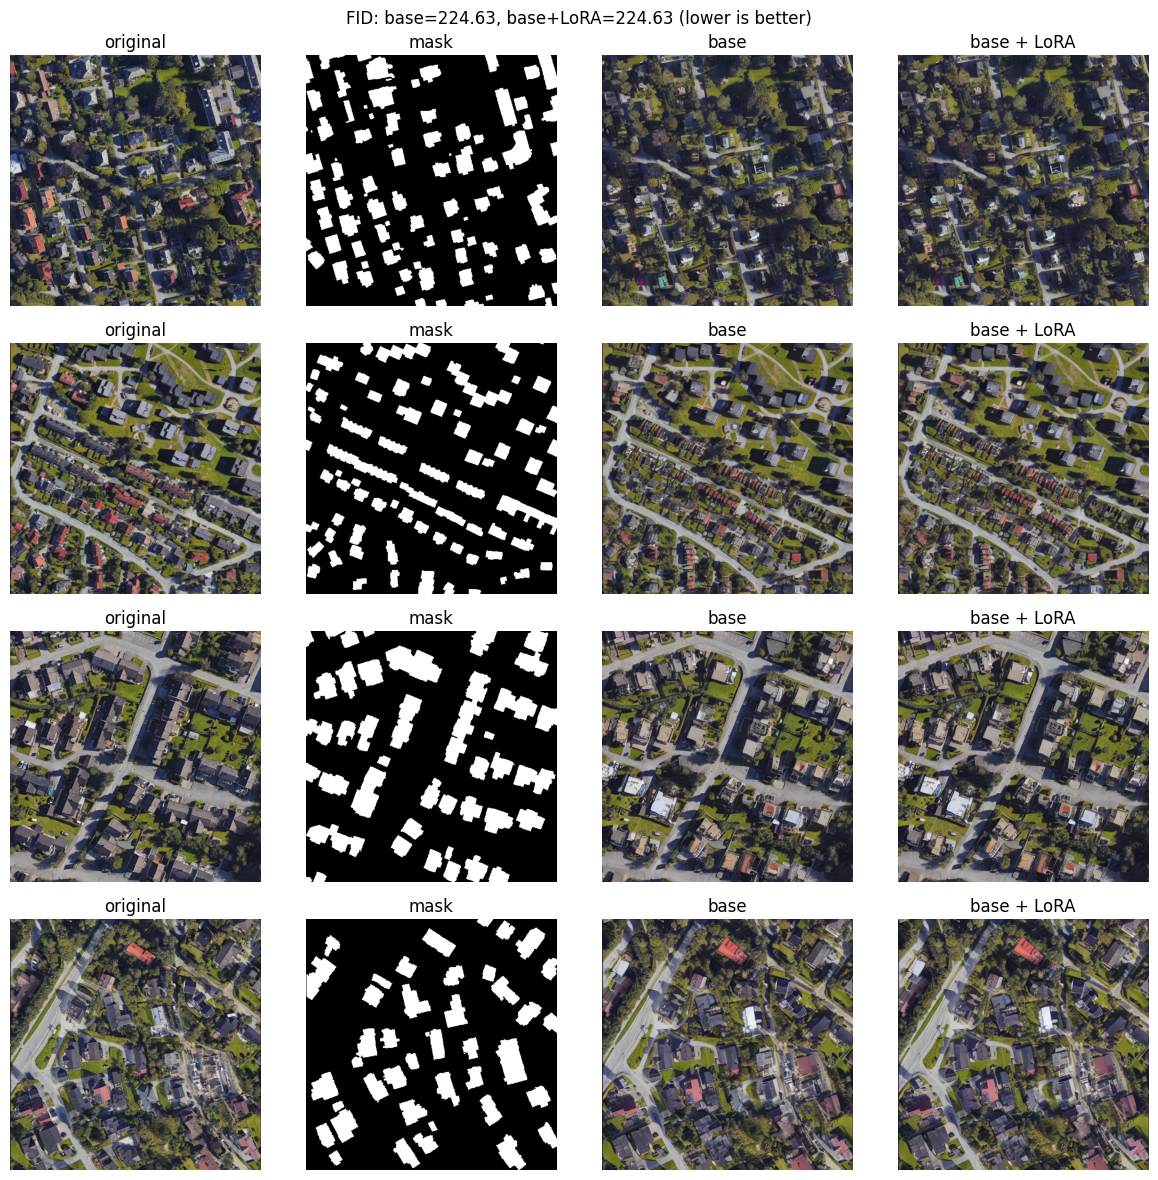

In [20]:
import matplotlib.pyplot as plt

# Show a compact visual audit: original, mask, base output, and LoRA output for each evaluated sample.
rows = len(pairs)
fig, axes = plt.subplots(rows, 4, figsize=(12, max(3, rows * 3)))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row, pair in enumerate(pairs):
    panels = [
        (load_image(pair.image_path), "original"),
        (load_mask(pair.mask_path), "mask"),
        (Image.open(base_paths[row]).convert("RGB"), "base"),
        (Image.open(lora_paths[row]).convert("RGB"), "base + LoRA"),
    ]
    for col, (image, title) in enumerate(panels):
        axes[row, col].imshow(image, cmap="gray" if title == "mask" else None)
        axes[row, col].set_title(title)
        axes[row, col].axis("off")

fig.suptitle(f"FID: base={base_fid:.2f}, base+LoRA={lora_fid:.2f} (lower is better)")
plt.tight_layout()
plt.show()